# **Trainning for Fraud detection :-**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import OneHotEncoder

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('new_data.csv')
df.sample(8)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
5145940,356,CASH_OUT,118526.44,C855100317,13620.00,0.00,C914574045,0.00,118526.44,0,0
5805771,401,TRANSFER,1254587.17,C956728373,0.00,0.00,C1284610653,6069948.72,7324535.89,0,0
2748725,212,PAYMENT,6209.25,C1081871813,1932.00,0.00,M2032244903,0.00,0.00,0,0
649717,35,CASH_IN,176001.88,C1158621686,53992.00,229993.88,C1549953877,389043.71,213041.83,0,0
3489369,258,CASH_OUT,130387.45,C1834202680,0.00,0.00,C581879680,494954.32,625341.77,0,0
1892341,165,CASH_IN,141811.91,C1854144571,5288760.01,5430571.92,C665250258,183999.29,42187.38,0,0
6223857,590,CASH_OUT,249407.84,C462653716,0.00,0.00,C1987208012,286718.15,536125.99,0,0
5030383,354,PAYMENT,7512.27,C150641130,97448.26,89936.00,M714251763,0.00,0.00,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## **Encoding:-**

In [ ]:
# type_mapping = {
#     "CASH_OUT": 0,
#     "PAYMENT": 1,
#     "CASH_IN":2,
#     "TRANSFER": 3,
#     "DEBIT":4
# }

# df['type_encoded'] = df['type'].map(type_mapping)

# df.sample(7)

In [ ]:
# encoder = OneHotEncoder(handle_unknown='ignore')
# encoded_cats = encoder.fit_transform(df[['type']])
# encoded_df = pd.DataFrame(encoded_cats.toarray(), columns=encoder.get_feature_names_out(['type']))

# joblib.dump(encoder, 'encoder.pkl')
# encoded_df.sample(7)

,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
2490942,1.0,0.0,0.0,0.0,0.0
2829328,0.0,1.0,0.0,0.0,0.0
2359789,0.0,0.0,1.0,0.0,0.0
1018557,0.0,0.0,0.0,0.0,1.0
4567204,0.0,0.0,0.0,1.0,0.0
1947106,0.0,1.0,0.0,0.0,0.0
2659775,1.0,0.0,0.0,0.0,0.0


### **Feature Extraction :-**


In [45]:
df['origin_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']
df.sample(6)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,origin_balance_change,dest_balance_change
5165692,358,PAYMENT,27633.54,C1916400199,0.0,0.00,M303536860,0.00,0.00,0,0,1,0.00,0.00
6118610,534,PAYMENT,3191.97,C1007276826,17222.0,14030.03,M1614915465,0.00,0.00,0,0,1,3191.97,0.00
4536837,326,CASH_OUT,48233.51,C700231836,26872.0,0.00,C1897111060,3641893.06,3690126.57,0,0,0,26872.00,48233.51
6011192,448,CASH_IN,188790.71,C1193388116,28413.0,217203.71,C1395877219,326349.20,137558.49,0,0,2,-188790.71,-188790.71
2128763,183,CASH_IN,308310.62,C1466709257,40496.0,348806.62,C522207417,0.00,0.00,0,0,2,-308310.62,0.00
840868,41,CASH_OUT,118164.45,C1643291748,190674.1,72509.65,C730999562,234880.90,353045.35,0,0,0,118164.45,118164.45


In [46]:
df['day'] = df['step'] // 24
df['hour'] = df['step'] % 24

def get_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(get_period)
df.sample(7)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,origin_balance_change,dest_balance_change,day,hour,time_period
3030963,233,PAYMENT,48450.98,C319460450,39423.19,0.00,M996750315,0.00,0.00,0,0,1,39423.19,0.00,9,17,Evening
5846722,402,PAYMENT,35023.08,C526676780,22166.00,0.00,M572861563,0.00,0.00,0,0,1,22166.00,0.00,16,18,Evening
1184174,132,PAYMENT,1943.89,C15413300,108893.00,106949.11,M431333285,0.00,0.00,0,0,1,1943.89,0.00,5,12,Afternoon
2523127,205,CASH_IN,30347.19,C161053192,6492537.98,6522885.17,C1120604771,1165244.16,1134896.97,0,0,2,-30347.19,-30347.19,8,13,Afternoon
3488323,258,PAYMENT,6114.24,C1649445076,10766.00,4651.76,M1282255482,0.00,0.00,0,0,1,6114.24,0.00,10,18,Evening
2849273,227,CASH_OUT,119218.97,C1126869181,0.00,0.00,C1894675147,313087.35,432306.32,0,0,0,0.00,119218.97,9,11,Morning
4890594,349,CASH_OUT,150836.11,C154089686,0.00,0.00,C1602448622,2307018.76,2457854.88,0,0,0,0.00,150836.12,14,13,Afternoon


In [47]:
time_mapping = {
    'Night': 0,
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3
}

df['time_period_encoded'] = df['time_period'].map(time_mapping)

In [48]:
# plt.figure(figsize=(8,5))
# sns.barplot(
#     x='time_period',
#     y='isFraud',
#     data=df,
#     estimator='mean',
#     palette='viridis'
# )
# plt.title("Average Fraud Probability by Time Period")
# plt.xlabel("Time Period")
# plt.ylabel("Fraud Ratio")
# plt.show()

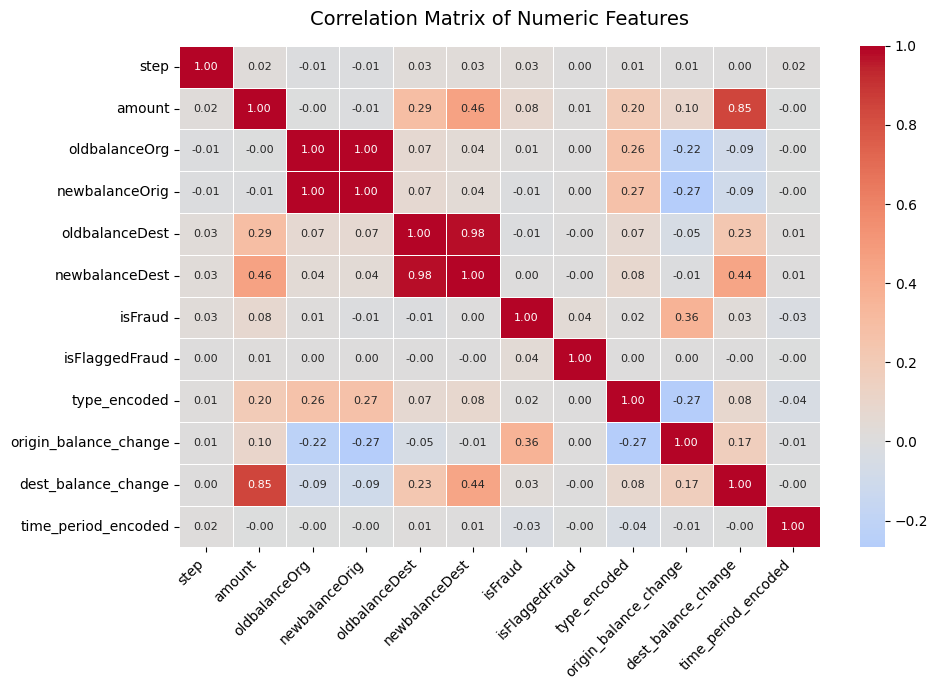


🔍 Top correlations with isFraud:

isFraud                  1.000000
origin_balance_change    0.362472
amount                   0.076688
isFlaggedFraud           0.044109
step                     0.031578
dest_balance_change      0.027028
type_encoded             0.016171
oldbalanceOrg            0.010154
newbalanceDest           0.000535
oldbalanceDest          -0.005885
newbalanceOrig          -0.008148
time_period_encoded     -0.026281
Name: isFraud, dtype: float64


In [49]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df = numeric_df.drop(columns=['day', 'hour'], errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix of Numeric Features", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n🔍 Top correlations with isFraud:\n")
print(corr_matrix['isFraud'].sort_values(ascending=False))


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   step                   int64  
 1   type                   object 
 2   amount                 float64
 3   nameOrig               object 
 4   oldbalanceOrg          float64
 5   newbalanceOrig         float64
 6   nameDest               object 
 7   oldbalanceDest         float64
 8   newbalanceDest         float64
 9   isFraud                int64  
 10  isFlaggedFraud         int64  
 11  type_encoded           int64  
 12  origin_balance_change  float64
 13  dest_balance_change    float64
 14  day                    int64  
 15  hour                   int64  
 16  time_period            object 
 17  time_period_encoded    int64  
dtypes: float64(7), int64(7), object(4)
memory usage: 873.8+ MB


In [51]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### **Model Trainning :-**

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [53]:
X = df.drop(["isFraud","day","step","type","nameOrig","nameDest","hour","time_period"],axis=1)
y = df["isFraud"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   oldbalanceOrg          float64
 2   newbalanceOrig         float64
 3   oldbalanceDest         float64
 4   newbalanceDest         float64
 5   isFlaggedFraud         int64  
 6   type_encoded           int64  
 7   origin_balance_change  float64
 8   dest_balance_change    float64
 9   time_period_encoded    int64  
dtypes: float64(7), int64(3)
memory usage: 485.4 MB


### **Imbalanced data handeling :-**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [55]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.75, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train.shape

(8896170, 10)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

### **Scaling : -**

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled

joblib.dump(scaler, 'scaler1.pkl')

['scaler1.pkl']

### **Logistic Regression : -**

In [58]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression( random_state=42)

log_model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1] * 100
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.22      0.36   1270881
           1       0.00      1.00      0.00      1643

    accuracy                           0.22   1272524
   macro avg       0.50      0.61      0.18   1272524
weighted avg       1.00      0.22      0.36   1272524

AUC Score: 0.8957036090849804
Confusion Matrix:
 [[279435 991446]
 [     0   1643]]


In [60]:
y_proba = log_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.3).astype(int)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/Users/yuvrajbhatkariya/data/VScode.C++/Projects/FraudDetection/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92   1270881
           1       0.01      0.99      0.02      1643

    accuracy                           0.85   1272524
   macro avg       0.50      0.92      0.47   1272524
weighted avg       1.00      0.85      0.92   1272524

AUC Score: 0.8957036090849804
Confusion Matrix:
 [[1080117  190764]
 [     19    1624]]


In [84]:
# y_pred = log_model.predict(X_test_scaled)


# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [62]:
joblib.dump(log_model, 'log_fraud_model1.pkl')

['log_fraud_model1.pkl']

### **Random Forest:-**

In [63]:
# from sklearn.ensemble import RandomForestClassifier
# rf_model = RandomForestClassifier(
#     n_estimators=100,           
#     max_depth=15,            
#     min_samples_split=2,
#     class_weight='balanced',    
#     random_state=42
# )
# rf_model.fit(X_train, y_train)

In [64]:
# import joblib


# joblib.dump(rf_model, 'xgb_fraud_model.pkl')


In [65]:
# y_pred = rf_model.predict(X_test)
# y_prob = rf_model.predict_proba(X_test)[:, 1] * 100

# print("🔍 Random Forest Results")     
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# print("AUC Score:", roc_auc_score(y_test, y_prob))

### **Xgboost :-**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [67]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train.shape

(7116936, 10)

In [76]:
import xgboost as xgb

# Compute scale_pos_weight
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])


xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [79]:
from sklearn.metrics import f1_score
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1] * 100

print("⚡ XGBoost Results")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))

⚡ XGBoost Results
[[1899736    6586]
 [     51    2413]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.27      0.98      0.42      2464

    accuracy                           1.00   1908786
   macro avg       0.63      0.99      0.71   1908786
weighted avg       1.00      1.00      1.00   1908786

AUC Score: 0.9993419847215614


In [81]:
# 1️⃣ Get probability predictions only for test data
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2️⃣ Find best threshold for F1-score
best_thresh = 0
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1 score:", best_f1)



Best threshold: 0.8899999999999996
Best F1 score: 0.6795749017324211


In [82]:
from sklearn.metrics import classification_report, confusion_matrix

final_preds = (y_proba >= best_thresh).astype(int)
print(confusion_matrix(y_test, final_preds))
print(classification_report(y_test, final_preds))


[[1904251    2071]
 [    130    2334]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.53      0.95      0.68      2464

    accuracy                           1.00   1908786
   macro avg       0.76      0.97      0.84   1908786
weighted avg       1.00      1.00      1.00   1908786



In [83]:
# y_pred = xgb_model.predict(X_test)
# y_prob = xgb_model.predict_proba(X_test)[:, 1] * 100

# print("⚡ XGBoost Results")
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))
# print("AUC Score:", roc_auc_score(y_test, y_prob))

# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
# plt.title("XGBoost Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [71]:
import joblib

joblib.dump(xgb_model, 'xgb_fraud_model1.pkl')

['xgb_fraud_model1.pkl']

In [73]:
import joblib
import pandas as pd

model = joblib.load('log_fraud_model1.pkl')
scaler = joblib.load('scaler1.pkl')

custom_data = {
    'amount': [200000.0],
    'oldbalanceOrg': [200000.0],
    'newbalanceOrig': [00.0],
    'oldbalanceDest': [200000.0],
    'newbalanceDest': [2000.0],
    'isFlaggedFraud': [0],
    'type_encoded': [0],             # e.g. 2 for 'TRANSFER' or 1 'PAYMENT'
    'origin_balance_change': [200000.0 - 200000.0],   # money sent by sender
    'dest_balance_change': [202000.0 - 2000.0],      # money received by receiver
    'time_period_encoded': [2]
}


custom_df = pd.DataFrame(custom_data)

custom_scaled = scaler.transform(custom_df)

prediction = model.predict(custom_scaled)
probability = model.predict_proba(custom_scaled)[:, 1]

print("🔍 Prediction:", "Fraud" if prediction[0] == 1 else "Not Fraud")
print("⚡ Fraud Probability:", round(probability[0], 4))


🔍 Prediction: Fraud
⚡ Fraud Probability: 1.0


In [74]:

model = joblib.load('xgb_fraud_model1.pkl')

custom_data = {
    'amount': [500000.0],
    'oldbalanceOrg': [500000.0],
    'newbalanceOrig': [0.0],
    'oldbalanceDest': [100.0],
    'newbalanceDest': [500100.0],
    'isFlaggedFraud': [0],
    'type_encoded': [0],  # e.g., 1=CASH-IN, 0=CASH-OUT, 4=DEBIT, 3=TRANSFER, 2=PAYMENT
    'origin_balance_change': [500000.0],  
    'dest_balance_change': [500000.0],      
    'time_period_encoded': [0]  # 0=Night, 1=Morning, 2=Afternoon, 3=Evening
}


custom_df = pd.DataFrame(custom_data)

prediction = model.predict(custom_df)
probability = model.predict_proba(custom_df)[:, 1]

print("🔍 Prediction:", "Fraud" if prediction[0] == 1 else "Not Fraud")
print("⚡ Fraud Probability:", round(probability[0], 4))


🔍 Prediction: Fraud
⚡ Fraud Probability: 0.9994


In [75]:
custom_data = {
    'amount': [250000.0],
    'oldbalanceOrg': [500000.0],
    'newbalanceOrig': [250000.0],
    'oldbalanceDest': [10000.0],
    'newbalanceDest': [260000.0],
    'isFlaggedFraud': [0],
    'type_encoded': [0],           
    'origin_balance_change': [250000.0],   
    'dest_balance_change': [250000.0],      
    'time_period_encoded': [0]
}

custom_df = pd.DataFrame(custom_data)

prediction = model.predict(custom_df)
probability = model.predict_proba(custom_df)[:, 1]

print("🔍 Prediction:", "Fraud" if prediction[0] == 1 else "Not Fraud")
print("⚡ Fraud Probability:", round(probability[0], 4))

🔍 Prediction: Not Fraud
⚡ Fraud Probability: 0.0009
